<a href="https://colab.research.google.com/github/relinxx/Deep-Learning/blob/practice-on-google-colab/implementing_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# The 'wget' command failed with a 404 Not Found error, meaning 'lab_utils_uni.py' could not be downloaded.
# Please verify the URL or provide the file directly.
!wget -nc https://raw.githubusercontent.com/deep-learning-applications/course1-v3/main/lab_utils_uni.py
import math, copy
import numpy as np
import matplotlib.pyplot as plt


--2026-05-06 19:10:18--  https://raw.githubusercontent.com/deep-learning-applications/course1-v3/main/lab_utils_uni.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-06 19:10:19 ERROR 404: Not Found.



In [ ]:
x_train = np.array([1.0, 2.0])
y_train =  np.array([200.0, 400])

In [ ]:
def compute_cost(x, y, w, b):
  m=x.shape[0]
  cost=0
  for i in range(m):
    f_wb=w*x[i]+b
    cost=cost + (f_wb-y[i])
  total_cost = 1/(2*m) * cost

  return total_cost

In [ ]:
def compute_gradient(x,y,w,b):
  m=x.shape[0]
  dj_dw = 0
  dj_db = 0

  for i in range(m):
    f_wb = w*x[i]+b
    dj_dw_i = (f_wb-y[i]) * x[i]
    dj_db_i = (f_wb-y[i])
    dj_db += dj_db_i
    dj_dw += dj_dw_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [ ]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, cost_func, gradient_func):
  j_history = [] #history of cost values
  p_history = [] #history of parameters

  b = b_in
  w=w_in

  for i in range(num_iter):
    dj_db, dj_dw = compute_gradient(x, y,w,b)

    #updaing parmeters
    w = w - alpha*dj_dw
    b = b - alpha*dj_db

    # Save cost J at each iteration
    if i<100000:      # prevent resource exhaustion
        j_history.append( cost_func(x, y, w , b))
        p_history.append([w,b])
  # Print cost every at intervals 10 times or as many iterations if < 10
    if i% math.ceil(num_iter/10) == 0:
        print(f"Iteration {i:4}: Cost {j_history[-1]:0.2e} ", f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",f"w: {w: 0.3e}, b:{b: 0.5e}")

  return w, b, j_history, p_history

In [ ]:
# initialize parameters
w_init = 0
b_init = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 0.001
# run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost -1.50e+02  dj_dw: -3.000e+02, dj_db: -5.000e+02   w:  3.000e-01, b: 5.00000e-01
Iteration 1000: Cost -2.62e+00  dj_dw: -5.278e+00, dj_db: -3.617e+01   w:  8.698e+01, b: 1.64289e+02
Iteration 2000: Cost 4.45e+00  dj_dw:  8.900e+00, dj_db: -1.611e+01   w:  8.216e+01, b: 1.85656e+02
Iteration 3000: Cost 5.16e+00  dj_dw:  1.032e+01, dj_db: -1.641e+01   w:  7.242e+01, b: 2.01689e+02
Iteration 4000: Cost 5.61e+00  dj_dw:  1.122e+01, dj_db: -1.775e+01   w:  6.165e+01, b: 2.18751e+02
Iteration 5000: Cost 6.09e+00  dj_dw:  1.217e+01, dj_db: -1.925e+01   w:  4.996e+01, b: 2.37240e+02
Iteration 6000: Cost 6.60e+00  dj_dw:  1.320e+01, dj_db: -2.087e+01   w:  3.727e+01, b: 2.57292e+02
Iteration 7000: Cost 7.16e+00  dj_dw:  1.432e+01, dj_db: -2.264e+01   w:  2.352e+01, b: 2.79037e+02
Iteration 8000: Cost 7.76e+00  dj_dw:  1.553e+01, dj_db: -2.455e+01   w:  8.606e+00, b: 3.02621e+02
Iteration 9000: Cost 8.42e+00  dj_dw:  1.684e+01, dj_db: -2.663e+01   w: -7.571e+00, b: 3.28198e+0

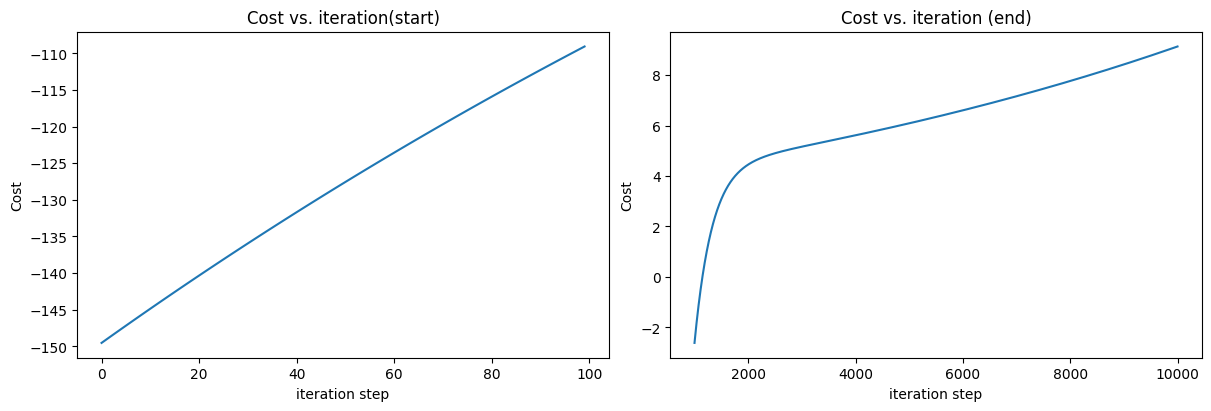

In [ ]:
# plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.show()

predictions

In [ ]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sqft house prediction 330.8 Thousand dollars
1200 sqft house prediction 325.8 Thousand dollars
2000 sqft house prediction 305.7 Thousand dollars
